# Additional Dataset Analysis and Results
## BIPN 162 Final Project
By Emily McClung, Naomi Ortega, and Isabel Rodriguez

We will now apply the DUNL analysis method to a Fiber Photometry dopamine spiking dataset from this paper by Seiler et al.: https://www.sciencedirect.com/science/article/pii/S0960982222001178?via%3Dihub 

### Packages set up and Data Wrangling

We will load in the data for 3 mice, each representing a different training condition
1. Mouse 1: Underwent the R160 random interval schedule of reinforcement and showed **punishment resistant reward seeking.** 
2. Mouse 2: Underwent the R160 random interval schedule of reinforcement and was **punishment sensitive.**
3. Mouse 3: Underwent the RR20 training of random ratio schedule. **Less habit formation**.

The data for each mouse contains 2 fiber photometry recording sessions. We will retrieve the dorsomedial striatum (DMS) recording signals and dorsolateral striatum (DLS) signals for each mouse, containing timestamps of nosepokes and rewards, for which time stamps are in units of seconds.

In [3]:
!pip install pynwb h5py torch scikit-learn configmypy tensorboardX

Defaulting to user installation because normal site-packages is not writeable


In [2]:
#CLone the DUNL algorithm GitHub Repository
!git clone https://github.com/btolooshams/dunl-compneuro.git

fatal: destination path 'dunl-compneuro' already exists and is not an empty directory.


In [40]:
import numpy as np
import torch
import sklearn
import h5py
import configmypy

import matplotlib.pyplot as plt

#Import the DUNL code
import sys
sys.path.append("dunl-compneuro/dunl")
#import dunl

#Imports for data
import os
from pynwb import NWBHDF5IO
os.makedirs("data", exist_ok=True)

In [4]:
!ls dunl-compneuro/dunl

__pycache__	     preprocess_scripts
boardfunc.py	     train_fiber_loop_acrossneurons.py
datasetloader.py     train_independentkernels_acrossneurons.py
lossfunc.py	     train_sharekernels_acrossneurons.py
model.py	     train_sharekernels_acrossneurons_groupneuralfirings.py
postprocess_scripts  utils.py


In [36]:
#Download the files to your home path by replacing with your own user- may take some time

In [ ]:
#download the dataset DANDI 000971
!pip install dandi
#download the specific files with the data we need
#RI60 PR (habit formation mimic)
!/home/emcclung/.local/bin/dandi download "https://dandiarchive.org/dandiset/000971/0.260213.1851/files?location=sub-028-392" --output-dir data

!/home/emcclung/.local/bin/dandi download "https://dandiarchive.org/dandiset/000971/0.260213.1851/files?location=sub-140-306" --output-dir data

!/home/emcclung/.local/bin/dandi download "https://dandiarchive.org/dandiset/000971/0.260213.1851/files?location=sub-100-258" --output-dir data

In [2]:
#specfic files we will look at
keep_files = {
"sub-028-392_ses-FP-PR-2020-07-24T12-31-24.nwb",
"sub-028-392_ses-FP-PR-2020-07-09T13-01-26.nwb",
"sub-140-306_ses-FP-PS-2019-08-09T12-10-58_behavior.nwb",
"sub-140-306_ses-FP-PS-2019-09-03T10-15-44_behavior.nwb",
"sub-100-258_ses-FP-RR20-2019-05-09T13-32-40_behavior.nwb",
"sub-100-258_ses-FP-RR20-2019-04-23T12-25-00_behavior.nwb"
}

data_dir = "data"
#delete unused files 
for root, dirs, files in os.walk(data_dir):
    for f in files:
        if f.endswith(".nwb") and f not in keep_files:
            path = os.path.join(root, f)
            os.remove(path)
    print("Deleted unused files")

Deleted unused files
Deleted unused files
Deleted unused files
Deleted unused files
Deleted unused files


In [41]:
#Group files by subject
dir_028 = "data/sub-028-392"
files_028 = [f for f in os.listdir(dir_028) if f.endswith(".nwb")]

dir_140 = "data/sub-140-306"
files_140 = [f for f in os.listdir(dir_140) if f.endswith(".nwb")]

dir_100 = "data/sub-028-258"
dir_100 = "data/sub-100-258"
files_100 = [f for f in os.listdir(dir_100) if f.endswith(".nwb")]

print(files_028)
print(files_140)
print(files_100)

['sub-028-392_ses-FP-PR-2020-07-24T12-31-24.nwb', 'sub-028-392_ses-FP-PR-2020-07-09T13-01-26.nwb']
['sub-140-306_ses-FP-PS-2019-08-09T12-10-58_behavior.nwb', 'sub-140-306_ses-FP-PS-2019-09-03T10-15-44_behavior.nwb']
['sub-100-258_ses-FP-RR20-2019-04-23T12-25-00_behavior.nwb', 'sub-100-258_ses-FP-RR20-2019-05-09T13-32-40_behavior.nwb']


In [42]:
#extracts dms_signal, dls_signal, and timestamps from files
def load_fp_signal(file_path):

    with NWBHDF5IO(file_path, "r") as io:
        nwb = io.read()
        
        #behavior = nwb.processing['behavior'] // 
        #print(behavior.data_interfaces.keys())
        #was looking at the behavior contained in the data: nosepokes and rewards
        
        fp_series = nwb.acquisition['fiber_photometry_response_series']
        raw_signal = fp_series.data[:]

        rate = fp_series.rate
        start = fp_series.starting_time
        timestamps = start + (np.arange(len(raw_signal)) / rate)

        dms_signal = raw_signal[:,0]
        dls_signal = raw_signal[:,2]

    return dms_signal, dls_signal, timestamps

### Changes made to configurations in the dunl-compneuro repo:
We made these changes to the configurations of the repo in order to use their code with new data.

1. In `config/dopamine_fiberphotometry_saramatias_uchida_config_1window_1kernel.yaml`
* changed **from** `data_folder:  "../data/dopamine-spiking-eshel-uchida"`
**to** `data_folder: "data/dls_sessions.pt"`
* change train_num_epochs: from **1000** to **100**. This is key for reducing training time from 1 hour to under 10 minutes.

2. In `dunl/train_fiber_loop_acrossneurons.py ` First, inside `init_params()`
 **set** `default="dunl-compneuro/config"`
to follow the correct path. Second, confirm that `default="./dopamine_calcium_saramatias_uchida_config.yaml"` is the line that is commented out, and all the other default lines are. Since 000971 data is FP, it uses the calcium setting. (recreation used spiking setting)

3. In `config/dopamine_fiberphotometry_saramatias_uchida_config_1window_1kernel.yaml`, change number_of_window from 19 to 50 to make sure the reshaping works with the size of our data.

5. In `dunl/train_fiber_loop_acrossneurons.py`, in the init_params() change `dataset.y = dataset.y[0]` to `dataset.y = dataset.y[:, 0, :]` so that both of the 2 trials for each DUNL run get input, instead of just 1. **directly below** that line, added `dataset.y = dataset.y[:, :15000]` to force the signal cropping to 15000 because training was getting hung up at reshaping for dunl trial 6 due to long signal size.


7. In `dunl/datasetloader.py`
**added** `'import numpy'`
inside `init()`**added** `with torch.serialization.safe_globals([numpy.core.multiarray._reconstruct]):
            data = torch.load(data_path, weights_only=False)`. Note: this one is necessary for newer PyTorch versions only (for Naomi it didn't work with this change)

------------------------------------------------------------------------------------------------
**THESE LAST 3 CHANGES TO  `config/dopamine_fiberphotometry_saramatias_uchida_config_1window_1kernel.yaml` WERE MADE TO RUN DUNL WITH 3 LEARNED KERNELS. EVALUATION SHOWED THAT 2 KERNELS WERE UNUSED. SO THEN THESE CHANGES WERE REVERSED BACK TO THE ORIGINAL, AND TRAINING WAS RUN WITH `kernel_num: 1`, etc.**
* change `kernel_num: 1` to `kernel_num: 3` so that DUNL can learn 3 kernels. the default was 1.
* change `kernel_nonneg_indicator: [1]` to `kernel_nonneg_indicator: [1,1,1]` (this parameter must be changed to allow 3 kernels in accordance with the above change)
* change `code_nonneg: [1]` to `code_nonneg: [1,1,1]` also to align with allowing 3 kernels.

In [15]:
#!rm-r folderpath/foldername
!rm -r results/z_sara_bahareh_final

# Exploratory Visualizations

insert isabel's vizs here

# Data Analysis

## DUNL Runs
We perform DUNL on the 3 mice. For each mouse, DUNL is run on both the DMS data and the DLS data, for a total of 6 total DUNL runs.

## Mouse 1: A Punishment Resistant Mouse trained with random interval schedule of reinforcement (R160)

In [11]:
#initalize lists
dms_sessions = []
dls_sessions = []

#loop through files and load signals
for f in files_028:
    file_path = os.path.join(dir_028, f)
    dms, dls, timestamps = load_fp_signal(file_path)
    dms_sessions.append(dms)
    dls_sessions.append(dls)

#convert lists to object arrays
dms_sessions = np.array(dms_sessions, dtype=object)
dls_sessions = np.array(dls_sessions, dtype=object)

#find the shortest session length to ensure uniform matrix dimensions
min_len = min(len(s) for s in dms_sessions)

#trim sessions to the minimum length and add the 'neuron' dimension (axis 1)
#shape: (num_trials, 1, trial_length)
dms_matrix = np.array([s[:min_len] for s in dms_sessions])[:, np.newaxis, :]
dls_matrix = np.array([s[:min_len] for s in dls_sessions])[:, np.newaxis, :]

#define dimensions for metadata
num_trials, num_neurons, trial_length = dls_matrix.shape

#define a helper to package and save as PyTorch tensors immediately
def save_as_tensor_dict(matrix, filename):
    tensor_dict = {
        "y": torch.as_tensor(matrix, dtype=torch.float32),
        "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
        "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
        "type": torch.zeros(num_trials, dtype=torch.int64)
    }
    torch.save(tensor_dict, filename)
    return tensor_dict

#save processed data
dms_sessions_fixed = save_as_tensor_dict(dms_matrix, "data/dms_sessions.pt")
dls_sessions_fixed = save_as_tensor_dict(dls_matrix, "data/dls_sessions.pt")

#verify types and shapes
for key, value in dls_sessions_fixed.items():
    print(f"DLS {key}: {type(value)} | Shape: {value.shape}")

DLS y: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 1124608])
DLS x: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 1])
DLS a: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 1])
DLS type: <class 'torch.Tensor'> | Shape: torch.Size([2])


## Brain area: DLS
DUNL 1/6

In [141]:
# For each run of DUNL, the input is 2 sessions.

original_data = torch.as_tensor(dls_matrix, dtype=torch.float32)
print(original_data.shape[2]) #the total recording duration was 1,124,608 × 0.000983 = 1105 seconds
#= 18.4 minutes

#keep first 15000 timepoints of each session
y_small = original_data[:, :, :15000]

num_trials = y_small.shape[0]
num_neurons = y_small.shape[1]

dls_test_set = {
    "y": y_small,
    "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "type": torch.zeros(num_trials, dtype=torch.int64)
}

torch.save(dls_test_set, "data/dls_sessions.pt")

print("New shape:", y_small.shape)
print("2 trials, 1 neuron, 15000 time points")
print("Points per window:", y_small.shape[2] // 50)

1124608
New shape: torch.Size([2, 1, 15000])
2 trials, 1 neuron, 15000 time points
Points per window: 300


In [138]:
!python dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py
#training completed and results were saved in the 971_dunl_results folder.
#(accidentally ran the cell again which overwrote the 100% progress output)

init parameters.
neuron_index 0
Train DUNL on neural data (independent kernels for each neuron).
device is cuda:0
Exp: fiber
create dataset and dataloader.
There 1 dataset in the folder.
data/dls_sessions.pt
x is shared among neurons. It is a function of trials, and number of kernels!
create board.
x is shared among neurons. It is a function of trials, and number of kernels!
This script has a hardcoded step for dataset processing.
these are hardcoded now! should be moved into pre-processing step.
create model.
create optimizer and scheduler for training.
start training.
  1%|▍                                          | 1/100 [00:06<11:17,  6.85s/it]
Traceback (most recent call last):
  File "/home/n2ortega/BIPN 162/BIPN_162_Final/dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py", line 387, in <module>
    main(params, random_date)
  File "/home/n2ortega/BIPN 162/BIPN_162_Final/dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py", line 234, in main
    for idx, (y_load, x_load, a

### Preliminary evaluation of DUNL results
After DUNL ran 1 time, the outputs of the learned kernels were evaluated. Since Tolooshams et al. recovered 3 learned kernels for their dopamine spiking data analysis, we first set DUNL to learn 3 kernels. The code below revealed that not all 3 kernels were being used.

In [130]:
import sys

sys.path.append("dunl-compneuro/dunl")
model = torch.load("971_dunl_results/3KERNELStrial1/model/model_final.pt", weights_only = False)
H = model.state_dict()['H']
print(H.shape) #There are 3 kernels, 1 channel, and 24 time bins. The 3 kernels matches the 3 kernels found in the paper.
H_np = H.detach().cpu().numpy() #convert the kernels from a tensor to a numpy array

torch.Size([3, 1, 30])


In [134]:
import torch
from datasetloader import DUNLdataset

device = torch.device("cpu")

# load model
net = torch.load("971_dunl_results/3KERNELStrial1/model/model_final.pt", map_location=device, weights_only = False)
net = net.to(device)
net.eval()

# load dataset
dataset = DUNLdataset("data/dls_sessions.pt")

# same preprocessing as training
dataset.y = torch.nan_to_num(dataset.y)
dataset.y = dataset.y - torch.min(dataset.y, dim=-1, keepdims=True)[0]
dataset.y /= torch.max(dataset.y, dim=-1, keepdims=True)[0]
dataset.y = dataset.y - torch.mean(dataset.y, dim=-1, keepdims=True)

dataset.y = dataset.y[:,0,:]
dataset.y = dataset.y[:,:15000]

# pick one neuron
y = dataset.y[0].unsqueeze(0).unsqueeze(0).float()

# move input to same device
y = y.to(device)

# run encoder
xhat, a_est = net.encode(y, None, None)

# bring results back to CPU for analysis
xhat = xhat.detach().cpu()

#don't allow unnecessary gradient tracking
with torch.no_grad():
    xhat, a_est = net.encode(y, None, None)


x is shared among neurons. It is a function of trials, and number of kernels!


In [135]:
xhat.shape

torch.Size([1, 3, 14971])

In [136]:
for k in range(3):
    code = xhat[0,k].detach().cpu().numpy()
    print(f"Kernel {k+1}: min={code.min()}, max={code.max()}, nonzero={(code!=0).sum()}")
k1 = xhat[0,0].detach().cpu().numpy()
k1_times = np.where(k1 > 0)[0]
print(k1_times)

Kernel 1: min=0.0, max=0.0, nonzero=0
Kernel 2: min=0.0, max=0.0, nonzero=0
Kernel 3: min=0.0, max=0.04205866530537605, nonzero=678
[]


**Findings:** Although it was specified for 3 kernels to be learned, the model only needed 1 kernel to model the signal in the dataset. So now, the configurations will be changed in the dunl-compneuro repo, and DUNL will be run for all 6 trials with only 1 kernel being created for each run.

### Brain area: DMS
DUNL 2/6

In [139]:
# For each run of DUNL, the input is 2 sessions.
#keep first 15000 timepoints of each session
original_data = torch.as_tensor(dms_matrix, dtype=torch.float32)

y_small = original_data[:, :, :15000]

num_trials = y_small.shape[0]
num_neurons = y_small.shape[1]

dms_test_set = {
    "y": y_small,
    "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "type": torch.zeros(num_trials, dtype=torch.int64)
}

torch.save(dms_test_set, "data/dms_sessions.pt")

print("New shape:", y_small.shape)
print("2 trials, 1 neuron, 15000 time points")
print("Points per window:", y_small.shape[2] // 50)

New shape: torch.Size([2, 1, 15000])
2 trials, 1 neuron, 15000 time points
Points per window: 300


In [9]:
!python dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py 

init parameters.
neuron_index 0
Train DUNL on neural data (independent kernels for each neuron).
device is cuda:0
Exp: fiber
create dataset and dataloader.
There 1 dataset in the folder.
data/dls_sessions.pt
x is shared among neurons. It is a function of trials, and number of kernels!
create board.
x is shared among neurons. It is a function of trials, and number of kernels!
This script has a hardcoded step for dataset processing.
these are hardcoded now! should be moved into pre-processing step.
create model.
create optimizer and scheduler for training.
start training.
100%|█████████████████████████████████████████| 100/100 [03:55<00:00,  2.36s/it]


## Mouse 2: A Punishment Sensitive R160 Mouse

In [17]:
#initalize lists
dms_sessions = []
dls_sessions = []

#loop through files and load signals
for f in files_140:
    file_path = os.path.join(dir_140, f)
    dms, dls, timestamps = load_fp_signal(file_path)
    dms_sessions.append(dms)
    dls_sessions.append(dls)

#convert lists to object arrays
dms_sessions = np.array(dms_sessions, dtype=object)
dls_sessions = np.array(dls_sessions, dtype=object)

#find the shortest session length to ensure uniform matrix dimensions
min_len = min(len(s) for s in dms_sessions)

#trim sessions to the minimum length and add the 'neuron' dimension (axis 1)
#shape: (num_trials, 1, trial_length)
dms_matrix = np.array([s[:min_len] for s in dms_sessions])[:, np.newaxis, :]
dls_matrix = np.array([s[:min_len] for s in dls_sessions])[:, np.newaxis, :]

#define dimensions for metadata
num_trials, num_neurons, trial_length = dls_matrix.shape

#fefine a helper to package and save as PyTorch tensors immediately
def save_as_tensor_dict(matrix, filename):
    tensor_dict = {
        "y": torch.as_tensor(matrix, dtype=torch.float32),
        "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
        "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
        "type": torch.zeros(num_trials, dtype=torch.int64)
    }
    torch.save(tensor_dict, filename)
    return tensor_dict

#save processed data
dms_sessions_fixed = save_as_tensor_dict(dms_matrix, "data/dms_sessions.pt")
dls_sessions_fixed = save_as_tensor_dict(dls_matrix, "data/dls_sessions.pt")

#verify types and shapes
for key, value in dls_sessions_fixed.items():
    print(f"DLS {key}: {type(value)} | Shape: {value.shape}")

DLS y: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 3743488])
DLS x: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 1])
DLS a: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 1])
DLS type: <class 'torch.Tensor'> | Shape: torch.Size([2])


### Brain area: DLS
DUNL 3/6

In [18]:
# For each run of DUNL, the input is 2 sessions.
#keep first 15000 timepoints of each session
original_data = torch.as_tensor(dls_matrix, dtype=torch.float32)

y_small = original_data[:, :, :15000]

num_trials = y_small.shape[0]
num_neurons = y_small.shape[1]

dls_test_set = {
    "y": y_small,
    "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "type": torch.zeros(num_trials, dtype=torch.int64)
}

torch.save(dls_test_set, "data/dls_sessions.pt")

print("New shape:", y_small.shape)
print("2 trials, 1 neuron, 15000 time points")
print("Points per window:", y_small.shape[2] // 50)

New shape: torch.Size([2, 1, 15000])
2 trials, 1 neuron, 15000 time points
Points per window: 300


In [19]:
!python dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py 

init parameters.
neuron_index 0
Train DUNL on neural data (independent kernels for each neuron).
device is cuda:0
Exp: fiber
create dataset and dataloader.
There 1 dataset in the folder.
data/dls_sessions.pt
x is shared among neurons. It is a function of trials, and number of kernels!
create board.
x is shared among neurons. It is a function of trials, and number of kernels!
This script has a hardcoded step for dataset processing.
these are hardcoded now! should be moved into pre-processing step.
create model.
create optimizer and scheduler for training.
start training.
100%|█████████████████████████████████████████| 100/100 [03:54<00:00,  2.35s/it]


### Brain area: DMS
DUNL 4/6

In [22]:
# For each run of DUNL, the input is 2 sessions.
#keep first 15000 timepoints of each session
original_data = torch.as_tensor(dms_matrix, dtype=torch.float32)

y_small = original_data[:, :, :15000]

num_trials = y_small.shape[0]
num_neurons = y_small.shape[1]

dms_test_set = {
    "y": y_small,
    "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "type": torch.zeros(num_trials, dtype=torch.int64)
}

torch.save(dms_test_set, "data/dms_sessions.pt")

print("New shape:", y_small.shape)
print("2 trials, 1 neuron, 15000 time points")
print("Points per window:", y_small.shape[2] // 50)

New shape: torch.Size([2, 1, 15000])
2 trials, 1 neuron, 15000 time points
Points per window: 300


In [23]:
!python dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py 

init parameters.
neuron_index 0
Train DUNL on neural data (independent kernels for each neuron).
device is cuda:0
Exp: fiber
create dataset and dataloader.
There 1 dataset in the folder.
data/dls_sessions.pt
x is shared among neurons. It is a function of trials, and number of kernels!
create board.
x is shared among neurons. It is a function of trials, and number of kernels!
This script has a hardcoded step for dataset processing.
these are hardcoded now! should be moved into pre-processing step.
create model.
create optimizer and scheduler for training.
start training.
100%|█████████████████████████████████████████| 100/100 [03:56<00:00,  2.37s/it]


## Mouse 3: RR20 Mouse

In [5]:
#initalize lists
dms_sessions = []
dls_sessions = []

#loop through files and load signals
for f in files_100:
    file_path = os.path.join(dir_100, f)
    dms, dls, timestamps = load_fp_signal(file_path)
    dms_sessions.append(dms)
    dls_sessions.append(dls)

#convert lists to object arrays
dms_sessions = np.array(dms_sessions, dtype=object)
dls_sessions = np.array(dls_sessions, dtype=object)

#find the shortest session length to ensure uniform matrix dimensions
min_len = min(len(s) for s in dms_sessions)

#trim sessions to the minimum length and add the 'neuron' dimension (axis 1)
#shape: (num_trials, 1, trial_length)
dms_matrix = np.array([s[:min_len] for s in dms_sessions])[:, np.newaxis, :]
dls_matrix = np.array([s[:min_len] for s in dls_sessions])[:, np.newaxis, :]

#define dimensions for metadata
num_trials, num_neurons, trial_length = dls_matrix.shape

#fefine a helper to package and save as PyTorch tensors immediately
def save_as_tensor_dict(matrix, filename):
    tensor_dict = {
        "y": torch.as_tensor(matrix, dtype=torch.float32),
        "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
        "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
        "type": torch.zeros(num_trials, dtype=torch.int64)
    }
    torch.save(tensor_dict, filename)
    return tensor_dict

#save processed data
dms_sessions_fixed = save_as_tensor_dict(dms_matrix, "data/dms_sessions.pt")
dls_sessions_fixed = save_as_tensor_dict(dls_matrix, "data/dls_sessions.pt")

#verify types and shapes
for key, value in dls_sessions_fixed.items():
    print(f"DLS {key}: {type(value)} | Shape: {value.shape}")

/home/n2ortega/.local/lib/python3.11/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines DichroicMirror.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines BandOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines EdgeOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
T

DLS y: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 3713536])
DLS x: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 1])
DLS a: <class 'torch.Tensor'> | Shape: torch.Size([2, 1, 1])
DLS type: <class 'torch.Tensor'> | Shape: torch.Size([2])


### Brain area: DLS
DUNL 5/6

In [55]:
# For each run of DUNL, the input is 2 sessions.
#keep first 15000 timepoints of each session
original_data = torch.as_tensor(dls_matrix, dtype=torch.float32)

y_small = original_data[:, :, :15000]

num_trials = y_small.shape[0]
num_neurons = y_small.shape[1]

dls_test_set = {
    "y": y_small,
    "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "type": torch.zeros(num_trials, dtype=torch.int64)
}

torch.save(dls_test_set, "data/dls_sessions.pt")

print("New shape:", y_small.shape)
print("2 trials, 1 neuron, 15000 time points")
print("Points per window:", y_small.shape[2] // 50)

New shape: torch.Size([2, 1, 15000])
2 trials, 1 neuron, 15000 time points
Points per window: 300


In [27]:
!python dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py 

init parameters.
neuron_index 0
Train DUNL on neural data (independent kernels for each neuron).
device is cuda:0
Exp: fiber
create dataset and dataloader.
There 1 dataset in the folder.
data/dls_sessions.pt
x is shared among neurons. It is a function of trials, and number of kernels!
create board.
x is shared among neurons. It is a function of trials, and number of kernels!
This script has a hardcoded step for dataset processing.
these are hardcoded now! should be moved into pre-processing step.
create model.
create optimizer and scheduler for training.
start training.
100%|█████████████████████████████████████████| 100/100 [03:55<00:00,  2.36s/it]


### Brain area: DMS
DUNL 6/6

In [11]:
# For each run of DUNL, the input is 2 sessions.
#keep first 15000 timepoints of each session
original_data = torch.as_tensor(dms_matrix, dtype=torch.float32)
print(dms_matrix.shape)
y_small = original_data[:, :, :15000]
print(y_small.shape)
num_trials = y_small.shape[0]
num_neurons = y_small.shape[1]

dms_test_set = {
    "y": y_small,
    "x": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "a": torch.zeros((num_trials, num_neurons, 1), dtype=torch.float32),
    "type": torch.zeros(num_trials, dtype=torch.int64)
}

torch.save(dms_test_set, "data/dms_sessions.pt")

print("New shape:", y_small.shape)
print("2 trials, 1 neuron, 15000 time points")
print("Points per window:", y_small.shape[2] // 50)

(2, 1, 3713536)
torch.Size([2, 1, 15000])
New shape: torch.Size([2, 1, 15000])
2 trials, 1 neuron, 15000 time points
Points per window: 300


In [12]:
!python dunl-compneuro/dunl/train_fiber_loop_acrossneurons.py 

init parameters.
neuron_index 0
Train DUNL on neural data (independent kernels for each neuron).
device is cuda:0
Exp: fiber
create dataset and dataloader.
There 1 dataset in the folder.
data/dls_sessions.pt
x is shared among neurons. It is a function of trials, and number of kernels!
create board.
x is shared among neurons. It is a function of trials, and number of kernels!
This script has a hardcoded step for dataset processing.
these are hardcoded now! should be moved into pre-processing step.
create model.
create optimizer and scheduler for training.
start training.
100%|█████████████████████████████████████████| 100/100 [03:55<00:00,  2.35s/it]


## DUNL kernels visualizations

Now that DUNL training is complete, all the model results with their learned kernels will be loaded in

In [43]:
##load in the kernels from each DUNL analysis
modeldirectory = "971_dunl_results/z_sara_bahareh_final"
Dmodels = []
for i in range (1,7):
    path = f"{modeldirectory}/results {i}/model/model_final.pt"
    model = torch.load(path, weights_only = False)
    Dmodels.append(model)
print(len(Dmodels))
#the results from dunl run 1 are stored in Dmodels[0], from run 2 are in Dmodels[1], etc.


6


In [44]:
H0 = Dmodels[0].state_dict()['H']
print(H0.shape)

torch.Size([1, 1, 30])


In [45]:
#extract learned kernels from each models
Dmodelskernels = [m.state_dict()['H'].detach().cpu().numpy() for m in Dmodels]
print(len(Dmodelskernels)) #a list containing 6 (1,1,30) tensors
for model in Dmodelskernels:
    print(model.shape)

6
(1, 1, 30)
(1, 1, 30)
(1, 1, 30)
(1, 1, 30)
(1, 1, 30)
(1, 1, 30)


### Figure: Learned kernels
Unlike Tolooshams et al. where their DUNL model learned 3 distinct kernels, applying DUNL to Seiler et al.'s data produced just a single kernel to represent the dopamine activity in the striatal regions of all three mice.

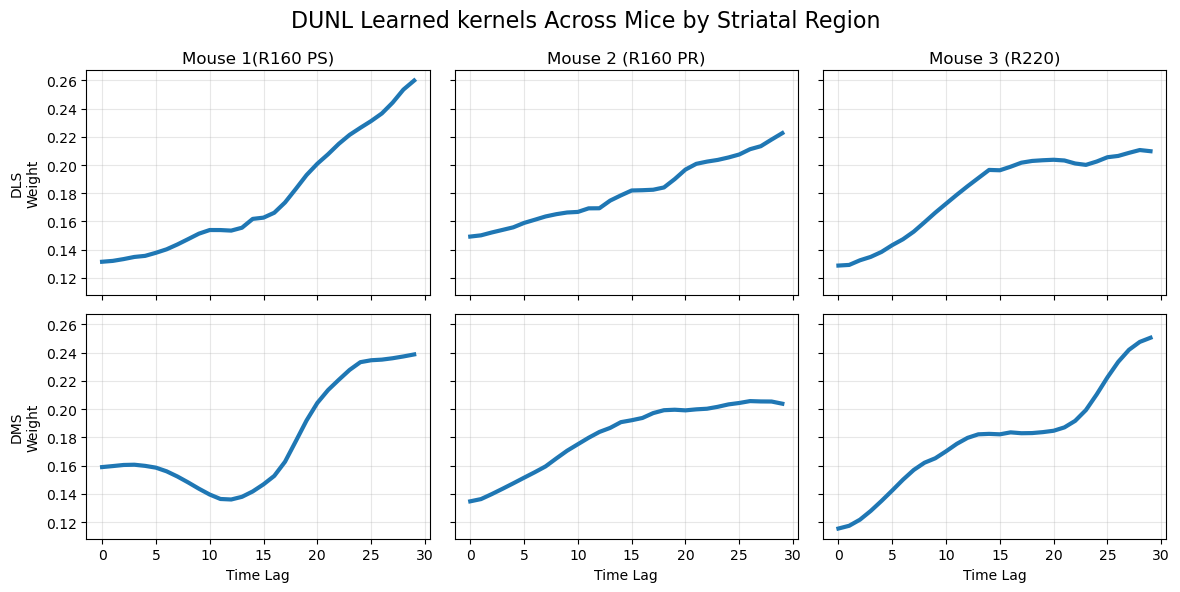

In [46]:
# Dmodelskernels = [m.state_dict()['H'].detach().cpu().numpy() for m in Dmodels]
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2,3, figsize=(12,6), sharex=True, sharey=True)
axes = axes.flatten()

#specify order so that all DMS runs will be top row, all DLS runs will be bottom row,
#and each column will correspond to the same mouse
order = [0, 3, 1, 4, 2, 5]
for i, H in enumerate(Dmodelskernels):

    ax = axes[order[i]]

    # H shape = (1,1,30)
    kernel = H.squeeze()   # -> (30,)

    x = np.arange(len(kernel))

    ax.plot(x, kernel, linewidth=3)

    #set x axis
    for i in [3,4,5]:
        axes[i].set_xlabel("Time Lag")
    #set y axis
    axes[0].set_ylabel("DLS\nWeight")
    axes[3].set_ylabel("DMS\nWeight")
    
    ax.grid(alpha=0.3)
    
    axes[0].set_title("Mouse 1(R160 PS)")
    axes[1].set_title("Mouse 2 (R160 PR)")
    axes[2].set_title("Mouse 3 (R220)")
    axes[3].set_title("")
    axes[4].set_title("")
    axes[5].set_title("")

fig.suptitle("DUNL Learned kernels Across Mice by Striatal Region", fontsize = 16)
plt.tight_layout()
plt.show()

This graph shows the learned kernel of dopamine events for each Mouse/ striatal area setting.
The DLS kernels show slower, more steady increase in dopamine. The DMS kernels for Mouse 1 and 3 show stronger fluctuations with more curvature. 

Loading in signals and event timings for each mouse so that they can be plotted with the kernels to visualize for what events the kernels are active.

### Figure: DUNL Detected Event times

In [47]:
####### loading in sessions for each mouse
# ---- Mouse 1 ----
timestamps_each_mouse = []
dms_sessions_1 = []
dls_sessions_1 = []

for f in files_028:
    file_path = os.path.join(dir_028, f)
    dms, dls, timestamps = load_fp_signal(file_path)
    
    
    #crop to training length
    dms = dms[:15000]
    dls = dls[:15000]
    timestamps = timestamps[:15000]
    
    timestamps_each_mouse.append(timestamps)
    dms_sessions_1.append(dms)
    dls_sessions_1.append(dls)


# ---- Mouse 2 ----
dms_sessions_2 = []
dls_sessions_2 = []

for f in files_140:
    file_path = os.path.join(dir_140, f)
    dms, dls, timestamps = load_fp_signal(file_path)

    #Crop to training length
    dms = dms[:15000]
    dls = dls[:15000]
    timestamps = timestamps[:15000]

    timestamps_each_mouse.append(timestamps)
    dms_sessions_2.append(dms)
    dls_sessions_2.append(dls)


# ---- Mouse 3 ----
dms_sessions_3 = []
dls_sessions_3 = []

for f in files_100:
    file_path = os.path.join(dir_100, f)
    dms, dls, timestamps = load_fp_signal(file_path)

     #Crop to training length
    dms = dms[:15000]
    dls = dls[:15000]
    timestamps = timestamps[:15000]

    timestamps_each_mouse.append(timestamps)
    dms_sessions_3.append(dms)
    dls_sessions_3.append(dls)

In [48]:
len(timestamps_each_mouse[4]) #length 6, each timestamp length 15000

15000

In [71]:
#use the first session for each mouse as the signal.
signals = [
    dls_sessions_1[0],  # Run 1  Mouse1 DLS (index 0 means first session)
    dms_sessions_1[0],  # Run 2  Mouse1 DMS
    dls_sessions_2[0],  # Run 3  Mouse2 DLS
    dms_sessions_2[0],  # Run 4  Mouse2 DMS
    dls_sessions_3[0],  # Run 5  Mouse3 DLS
    dms_sessions_3[0]   # Run 6  Mouse3 DMS
]
def preprocess_signal(signal):

    y = torch.tensor(signal).float()

    y = torch.nan_to_num(y)
    y = y - torch.min(y)
    y = y / torch.max(y)
    y = y - torch.mean(y)

    return y
signals = [preprocess_signal(s) for s in signals]

device = torch.device("cpu")

for m in Dmodels:
    m.to(device)
    m.eval()

all_xhat = []
all_event_bins = []

for i, model in enumerate(Dmodels):

    y = signals[i]

    y = y.unsqueeze(0).unsqueeze(0).to(device)

    a = torch.zeros(y.shape[0],1,1).to(device)

    with torch.no_grad():
        xhat, a_est = model.encode(y, a, None)

    xhat = xhat.detach().cpu()

    all_xhat.append(xhat)

    code = xhat[0,0].numpy()

    #detect dopamine event onset
    binary = code > 0.001
    event_bins = np.where((binary[1:] == 1) & (binary[:-1] == 0))[0]
    #event_bins = np.where(code > 0)[0]

    #event bins are indices between 0-15000 where the event occurred
    all_event_bins.append(event_bins)

    print(f"Run {i+1}: {len(event_bins)} dopamine events detected")
 


Run 1: 1 dopamine events detected
Run 2: 1 dopamine events detected
Run 3: 9 dopamine events detected
Run 4: 1 dopamine events detected
Run 5: 3 dopamine events detected
Run 6: 1 dopamine events detected


In [50]:
#see the time bins between 0 and 15000 where events occurred
print(all_event_bins[0])

[276]


In [72]:
#extracts nose-poke and reward timestamps
def load_behavior_events(file_path, max_time):

    with NWBHDF5IO(file_path, "r") as io:
        nwb = io.read()

        behavior = nwb.processing['behavior']

        poke_times = []
        reward_times = []

        for name, obj in behavior.data_interfaces.items():

            if "poke" in name.lower():
                poke_times = obj.timestamps[:]

            if "reward" in name.lower():
                reward_times = obj.timestamps[:]

    #filter signal window to 15000 samples to align with the DUNL input signal window
   # poke_times = poke_times[poke_times <= max_time]
   # reward_times = reward_times[reward_times <= max_time]
    

    return poke_times, reward_times

In [73]:
#get nosepoke and reward times for each 
subjects = [
    ("sub-028-392", dir_028, files_028[0]),
    ("sub-140-306", dir_140, files_140[0]),
    ("sub-100-258", dir_100, files_100[0])
]

rewards_all_trials = []
pokes_all_trials = []
for row, (subject, directory, file) in enumerate(subjects):

    path = os.path.join(directory, file)
    max_time = 111000
    pokes, rewards = load_behavior_events(path, max_time)
    pokes_all_trials.append(pokes)
    rewards_all_trials.append(rewards) #contains [reward times mouse 1, mouse 2, mouse 3]


#takes only the onsets of pokes and rewards
#instead of continuous tracking of a reward or poke taking place over time.
#this will match with how only the dopamine events were graphed.

gap_threshold = 0.1

poke_onsets_all_trials = []
reward_onsets_all_trials = []

for pokes in pokes_all_trials:
    diffs = np.diff(pokes)
    onsets = pokes[np.insert(diffs > gap_threshold, 0, True)]
    poke_onsets_all_trials.append(onsets)

for r in rewards_all_trials:
    diffs = np.diff(r)
    onsets = r[np.insert(diffs > gap_threshold, 0, True)]
    reward_onsets_all_trials.append(onsets)

#for plotting, make a list of rewards and pokes
rewards_list = [
    rewards_all_trials[0],
    rewards_all_trials[0],
    rewards_all_trials[1],
    rewards_all_trials[1],
    rewards_all_trials[2],
    rewards_all_trials[2]]
pokes_list = [
    poke_onsets_all_trials[0],
    poke_onsets_all_trials[0],
    poke_onsets_all_trials[1],
    poke_onsets_all_trials[1],
    poke_onsets_all_trials[2],
    poke_onsets_all_trials[2]]

rewards_list = [reward_onsets_all_trials[0],
                reward_onsets_all_trials[0],
                reward_onsets_all_trials[1],
                reward_onsets_all_trials[1],
                reward_onsets_all_trials[2],
                reward_onsets_all_trials[2]]

/home/emcclung/.local/lib/python3.11/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines DichroicMirror.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines BandOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines EdgeOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
T

In [74]:
print("max signal time:", timestamps[-1])
print("max poke bin:", np.max(pokes_list[i]))
print(len(poke_onsets_all_trials), '\n', pokes_all_trials[0])
#these pokes and rewards are on another bin scale
#39 corresponds to 39 × 0.000983 ≈ 0.038 seconds
#3589 corresponds to 3589 × 0.000983 ≈ 3.53 seconds

max signal time: 14.744616665107667
max poke bin: 3545.21563136
3 
 [   1.10575616    6.46578176    7.4858496     8.46577664    9.6559104
   11.31593728   13.38589184   19.42601728   85.26692352   99.58703104
  114.11718144  119.53733632  121.15738624  134.98744832  138.58766848
  140.18772992  144.46772224  150.29764096  152.29763584  153.94783232
  154.57779712  157.09782016  158.24781312  158.99787264  160.92790784
  162.79781376  164.35789824  165.19790592  166.35789312  167.47790336
  179.19803392  191.16818432  194.568192    218.75867648  221.08864512
  223.2287232   225.27868928  230.3787008   234.15881728  235.23885056
  241.25898752  243.50900224  244.3788288   245.14904064  246.78907904
  248.05900288  249.7191936   267.3393664   269.49926912  275.89935104
  277.9193344   279.51939584  280.9094144   282.75949568  283.3293312
  287.57950464  288.06955008  289.0694656   289.90947328  299.65975552
  301.38974208  303.88977664  304.30969856  307.00978176  307.75967744
  308.57986

In [75]:
print(timestamps_each_mouse[0].max())
dt = timestamps_each_mouse[0][1] - timestamps_each_mouse[0][0]
print("seconds per bin:", dt)
print("total seconds:", dt * 15000)
print("total minutes:", (dt * 15000) / 60)

14.744616665107667
seconds per bin: 0.0009830399803392004
total seconds: 14.745599705088006
total minutes: 0.2457599950848001


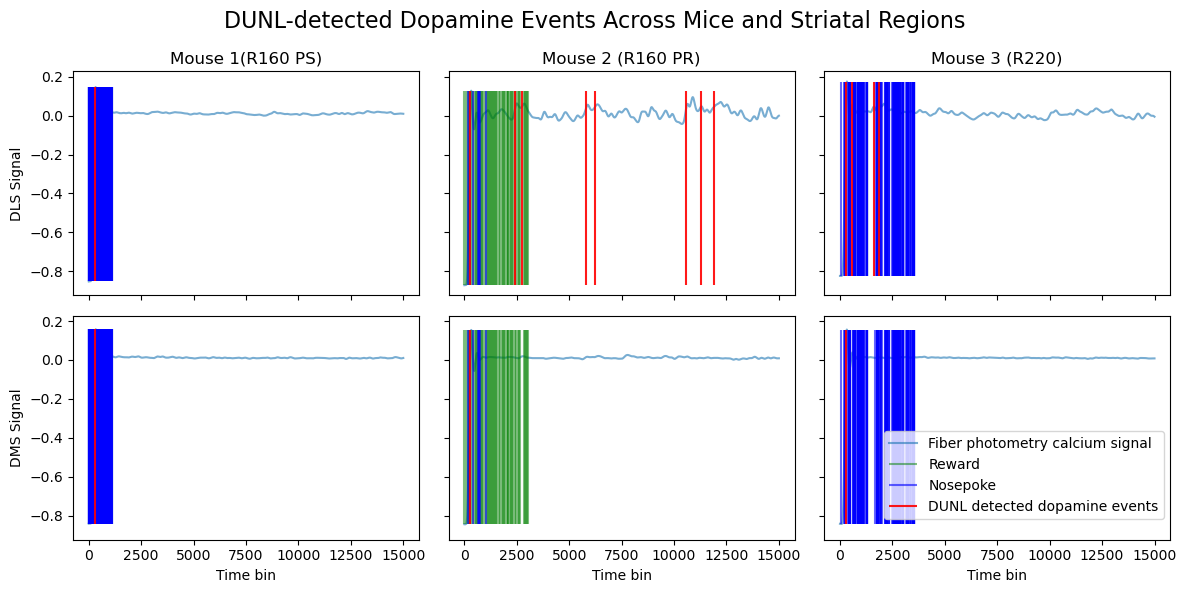

In [55]:
fig, axes = plt.subplots(2,3, figsize=(12,6), sharex=True, sharey=True)
axes = axes.flatten()

order = [0, 3, 1, 4, 2, 5]
titles = [
    "Mouse 1 DLS",
    "Mouse 2 DLS",
    "Mouse 3 DLS",
    "Mouse 1 DMS",
    "Mouse 2 DMS",
    "Mouse 3 DMS"
]
for i in range(6):
    ax = axes[order[i]]
    signal = signals[i].numpy()
    events = all_event_bins[i]

    #convert timestamps to time bins
    reward_bins = rewards_list[i]
    poke_bins = pokes_list[i]
   # reward_bins = np.searchsorted(timestamps_each_mouse[i], rewards_list[i])
   # poke_bins = np.searchsorted(timestamps_each_mouse[i], pokes_list[i])
    
    
    #plot calcium signal
    ax.plot(signal, alpha=0.6, label = "Fiber photometry calcium signal")
    
    #plot reward times
    ax.vlines(reward_bins,
              ymin=signal.min(),
              ymax=signal.max(),
              color='green',
              label="Reward",
                alpha = 0.5)
                
    #plot nosepoke times
    
    ax.vlines(poke_bins,
              ymin=signal.min(),
              ymax=signal.max(),
              color='blue',
              label="Nosepoke",
             alpha = 0.6)

     #plot dopamine events
   
    ax.vlines(events,
               ymin=signal.min(),
               ymax=signal.max(),
               color='red',
               alpha=0.9,
                label = "DUNL detected dopamine events")
'''
    import matplotlib.lines as mlines
# plot events
    ax.eventplot(
    [poke_bins, reward_bins],
    colors=["blue", "green"],
    lineoffsets=[-8, -0.78],
    alpha = 0.5
    )

# create legend entries
poke_line = mlines.Line2D([], [], color="blue", label="Nosepoke")
reward_line = mlines.Line2D([], [], color="green", label="Reward")

ax.legend(handles=[poke_line, reward_line])
'''
#axis titles
axes[0].set_title("Mouse 1(R160 PS)")
axes[1].set_title("Mouse 2 (R160 PR)")
axes[2].set_title("Mouse 3 (R220)")
axes[3].set_title("")
axes[4].set_title("")
axes[5].set_title("")

# axis labels
axes[3].set_xlabel("Time bin")
axes[4].set_xlabel("Time bin")
axes[5].set_xlabel("Time bin")

axes[0].set_ylabel("DLS Signal")
axes[3].set_ylabel("DMS Signal")

fig.suptitle("DUNL-detected Dopamine Events Across Mice and Striatal Regions", fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.98, 0.12))

plt.tight_layout()
plt.show()


The red bars indicate the times of activation of the learned kernel. They are onset of the detected dopamine events. DUNL itself does not identify whether the dopamine events were reward times or nosepoke times. Overlaying the rewards and nosepokes with the dopamine events showed what behavior was occuring when the learned DUNL kernel was activated. 

# Analysis

## Analysis 1: Dopamine Event Rate by Region

* On each mouse
* Get event rates for each region
* Perform a Wilcoxon signed-rank test

* With the hypothesis H0: event rate DLS = event rate DMS
* 
Python example:

from scipy.stats import wilcoxon

wilcoxon(dls_rates, dms_rates)

Visualization to go along side this: event rate bar plot

event rate
│
│   █ DLS
│
│   █ DMS
└──────────


### Analysis 3:  Dopamine event latency relative to reward and punishment by striatal region

This analaysis uses the Wilcoxon statistical test to compare the dopamine event probability between rewards and nosepokes between the DLS and DMS. 

Behavorial modulation is defined as the difference between the probability of a DUNL-detected dopamine event given a reward and the probability of a DUNL-detected dopamine event given a nosepoke.

The null hypothesis for the Wilcoxon test is: There is no difference in the behavioral modulation between DMLS and DMS.

In [132]:
def event_probability(event_times, behavior_times, window=15):

    count = 0

    for t in behavior_times:
        if np.any((event_times > t) & (event_times < t + window)):
            count += 1

    return count / len(behavior_times)

In [133]:
p_reward_dls = []
p_reward_dms = []

p_poke_dls = []
p_poke_dms = []

for mouse in range(3):

    dls_idx = mouse*2
    dms_idx = mouse*2 + 1

    rewards = rewards_all_trials[mouse]
    pokes = pokes_all_trials[mouse]

    dls_events = all_event_bins[dls_idx]
    dms_events = all_event_bins[dms_idx]

    p_reward_dls.append(event_probability(dls_events, rewards))
    p_reward_dms.append(event_probability(dms_events, rewards))

    p_poke_dls.append(event_probability(dls_events, pokes))
    p_poke_dms.append(event_probability(dms_events, pokes))

In [134]:
#behavioral modulation calculation for dls and dms
mod_dls = np.array(p_reward_dls) - np.array(p_poke_dls)
mod_dms = np.array(p_reward_dms) - np.array(p_poke_dms)
np.array(p_poke_dls)

array([0.00847458, 0.        , 0.        ])

In [135]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(mod_dls, mod_dms)

print("Wilcoxon statistic:", stat)
print("p-value:", p)

Wilcoxon statistic: 0.0
p-value: 0.17971249487899976


/home/emcclung/.local/lib/python3.11/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/emcclung/.local/lib/python3.11/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


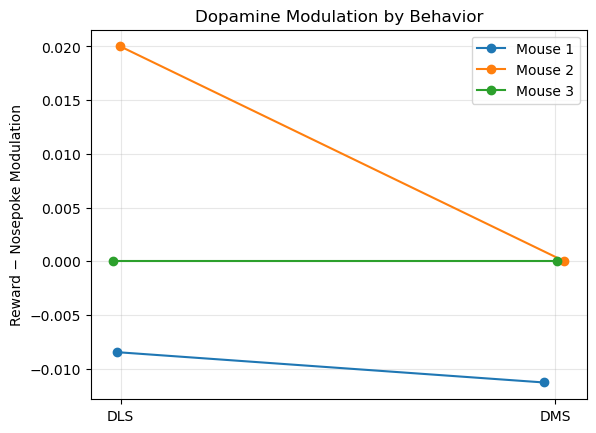

In [136]:
import numpy as np

plt.figure()

for i in range(len(mod_dls)):

    jitter = np.random.normal(0, 0.02, 2)

    plt.plot([0+jitter[0],1+jitter[1]],
             [mod_dls[i], mod_dms[i]],
             marker='o',
             label=f'Mouse {i+1}')

plt.xticks([0,1], ['DLS','DMS'])
plt.ylabel('Reward − Nosepoke Modulation')
plt.title('Dopamine Modulation by Behavior')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

* Mouse 1 shows a slightly more negative value in DMS meaning Dopamine events occur slightly more around nose-pokes than rewards, especially in DMS
* Mouse 2 shows a slight positive for DLS, and 0 for DMS, which suggests Dopamine activity appears similar for rewards and nose-pokes.
* Mouse 3 shows 0 difference in behavior modulation between the DLS and DMS.
#### Dopamine activity in the dorsolateral striatum may be somewhat more sensitive to reward-related events than the dorsomedial striatum, though effects vary across mice.